# Optional clients

In this short tutorial we introduce _optional_ clients which offer a reward (a prize) when they are serviced on a route, but whose service is not required for feasibility.
This routing variant is often called a prize-collecting vehicle routing problem, and PyVRP supports this out-of-the-box.

In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop

We will set different prize values for different clients.
This can be used to reflect different service priorities.

In [2]:
COORDS = [(456, 320), (312, 418), (114, 80), (570, 160), (684, 240)]
PRIZES = [500, 300, 500, 300]

.. important::
   When modelling optional clients, do not forget to provide both a reward (the `prize` argument to `add_client`), and to mark the client as optional by setting `required=False`!

In [3]:
m = pyvrp.Model()

m.add_depot(location=m.add_location(x=COORDS[0][0], y=COORDS[0][1]))
m.add_vehicle_type(1)

for idx in range(1, len(COORDS)):
    m.add_client(
        location=m.add_location(x=COORDS[idx][0], y=COORDS[idx][1]),
        prize=PRIZES[idx - 1],
        required=False,
    )

for frm in m.locations:
    for to in m.locations:
        distance = abs(frm.x - to.x) + abs(frm.y - to.y)
        m.add_edge(frm, to, distance=distance)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))

PyVRP v0.14.0


Solving an instance with:


    1 depot


    4 clients


    0 shipments


...

   objective: 1560


    distance: 1260


    duration: 0


# iterations: 67520


    run-time: 1.00 seconds


PyVRP quickly finds a solution visiting three clients.
Since the instance has four clients, one client is unvisited.
Let's visually investigate why:

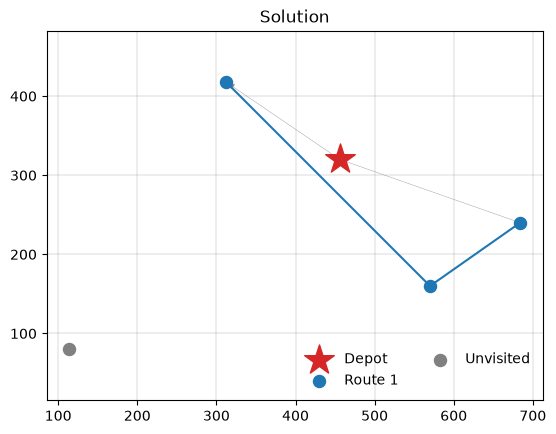

In [4]:
pyvrp.plotting.plot_solution(res.best, m.data(), plot_locations=True)

The three visited clients are all close to the depot, but the one unvisited client is not.
That's why PyVRP has decided not to service that client: the prize value is not sufficiently high to warrant a detour.

We can incentivise PyVRP to service this client either by setting a higher prize, or enforce service by making the client visit required.
Let's try to increase the prize, and solve the model again:

In [5]:
PRIZES[1] = 1_000

In [6]:
m = pyvrp.Model()

m.add_depot(location=m.add_location(x=COORDS[0][0], y=COORDS[0][1]))
m.add_vehicle_type(1)

for idx in range(1, len(COORDS)):
    m.add_client(
        location=m.add_location(x=COORDS[idx][0], y=COORDS[idx][1]),
        prize=PRIZES[idx - 1],
        required=False,
    )

for frm in m.locations:
    for to in m.locations:
        distance = abs(frm.x - to.x) + abs(frm.y - to.y)
        m.add_edge(frm, to, distance=distance)

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))

PyVRP v0.14.0


Solving an instance with:


    1 depot


    4 clients


    0 shipments


...

   objective: 1816


    distance: 1816


    duration: 0


# iterations: 59772


    run-time: 1.00 seconds


With the prize increase, visiting all clients is now worthwhile:

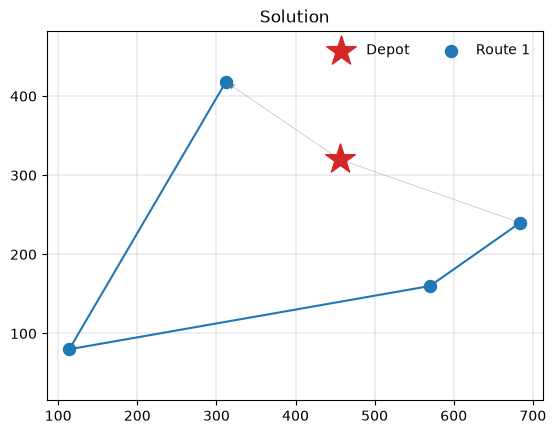

In [7]:
pyvrp.plotting.plot_solution(res.best, m.data(), plot_locations=True)

## Conclusion

In this tutorial you have learned about modelling optional clients using PyVRP, and incentivising the solver to visit optional clients using the client's `prize` attribute.
Optional clients are very helpful to ensure a feasible solution is always obtained, even when there are constraints that prevent PyVRP from servicing all clients.
Furthermore, different prizes can be used to model different client priorities: all else equal, PyVRP will prefer to service a higher-prize client over one where it collects a lower prize. 